# Comprehensive Anomaly Detection Benchmark: Cardiotocography Dataset

This notebook implements an end-to-end anomaly detection and classification pipeline evaluated on the Cardiotocography (`cardio.mat`) dataset from the ODDS (Outlier Detection DataSets) repository.

#### Pipeline Architecture

1. **Data Ingestion & Preprocessing**: Data retrieval, stratified train/test split (70/30), and $z$-score standardization fitted exclusively on normal samples.
2. **Linear Baseline**: Principal Component Analysis (PCA) decoupled into Squared Prediction Error (SPE) and Hotelling's $T^2$ with Jackson-Mudholkar limits.
3. **Tree-Based Baseline**: Isolation Forest optimized via Bayesian hyperparameter tuning with Optuna.
4. **Supervised Boosting Baseline**: LightGBM and CatBoost with isotonic calibration and $F_2$-score threshold optimization via `TunedThresholdClassifierCV`.
5. **Industrial Deep Learning**: H2O Deep Learning AutoEncoder featuring a trimmed re-training loop.
6. **Probabilistic Generative Core**: PyTorch Tabular Variational Autoencoder (VAE) optimized with Evidence Lower Bound (ELBO) and hybrid scoring ($\text{MSE} + \beta \cdot \text{KL}$).
7. **Modern Tabular Deep Learning**: TabNet (sequential attention) trained with early stopping; $F_2$ threshold selected on a validation set only.
8. **Automated Machine Learning (AutoML Core)**: AutoGluon `TabularPredictor` (`best_quality` preset, 3-fold bagging, 1 stack level) trained with a custom probabilistic scoring metric (`brier_binary`) and post-hoc threshold calibration across multiple cost objectives.
9. **Master Benchmark & Cross-Paradigm Analysis**: Comprehensive metrics comparison ($\text{ROC-AUC}$, $\text{PR-AUC}$, $\text{Brier Score}$) and Spearman rank correlation matrix across continuous anomaly outputs.


## Environment Setup and Dependencies Installation

In [ ]:
!pip install --quiet h2o  #scipy matplotlib seaborn scikit-learn tensorflow torch

!pip install -q feature-engine --no-deps
!pip install catboost
!pip install skrub gradio optuna-integration

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 MB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.7/802.7 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 23.9 MB/s eta 0:00:00


In [ ]:
import os
import random
import urllib.request
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy import stats
import seaborn as sns
from tabulate import tabulate

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Global deterministic seed configuration
SEED = 12345
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)



warnings.filterwarnings("ignore")
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
plt.rcParams["figure.dpi"] = 100


In [ ]:
# Ingestion and Scaling


# Download cardio.mat from ODDS dataset repository
data_url = "http://www.getdata.io/datasets/cardio.mat" # Fallback mirror or official URL
local_filename = "cardio.mat"

try:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/yzhao062/pyod/master/notebooks/data/cardio.mat", local_filename)
except Exception:
    urllib.request.urlretrieve("http://odds.nci.nih.gov/mat/cardio.mat", local_filename)

# Load Matlab structure
mat_data = sio.loadmat(local_filename)
X_raw = mat_data['X']
y_raw = mat_data['y'].ravel().astype(int)

print(f"Dataset shape: {X_raw.shape}")
print(f"Total samples: {X_raw.shape[0]} | Anomalies (y=1): {int(np.sum(y_raw))} ({np.mean(y_raw)*100:.2f}%)")

# Stratified Train/Test split (70% Train, 30% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=SEED, stratify=y_raw
)

# Standardize features using training statistics
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Extract normal instances for semi-supervised autoencoder training
X_train_normal = X_train[y_train == 0]

print(f"Training set: {X_train.shape[0]} samples (Normal only for AE: {X_train_normal.shape[0]})")
print(f"Testing set:  {X_test.shape[0]} samples (Anomalies in test: {int(np.sum(y_test))})")

Dataset shape: (1831, 21)
Total samples: 1831 | Anomalies (y=1): 176 (9.61%)
Training set: 1281 samples (Normal only for AE: 1158)
Testing set:  550 samples (Anomalies in test: 53)


## 2. Linear Baseline: PCA (SPE vs. Hotelling's $T^2$)

### Theoretical Mechanism
Principal Component Analysis orthogonalizes the feature space into principal and residual subspaces:
1. **Principal Subspace ($k$ components)**: Quantified by Hotelling's $T^2$, measuring in-plane Mahalanobis distance under the major variation directions.
2. **Residual Subspace ($d - k$ components)**: Quantified by Squared Prediction Error ($\text{SPE}$), measuring orthogonal reconstruction distance due to correlation breakdowns.

$$\text{SPE}_i = \|\mathbf{x}_i - \hat{\mathbf{x}}_i\|_2^2 = \|\mathbf{x}_i - \mathbf{V}_k \mathbf{V}_k^T \mathbf{x}_i\|_2^2$$

$$T^2_i = \sum_{j=1}^{k} \frac{t_{ij}^2}{\lambda_j} = \mathbf{x}_i^T \mathbf{V}_k \mathbf{\Lambda}_k^{-1} \mathbf{V}_k^T \mathbf{x}_i$$

### Statistical Control Limits
Using Jackson-Mudholkar approximations ($\alpha = 0.05$), theoretical Upper Control Limits ($\text{UCL}$) define normal operation boundaries:

$$UCL_{T^2} = \frac{k(N-1)}{N-k} F_{\alpha, k, N-k}$$

$$UCL_{\text{SPE}} = \theta_1 \left[ \frac{z_\alpha \sqrt{2 \theta_2 h_0^2}}{\theta_1} + 1 + \frac{\theta_2 h_0 (h_0 - 1)}{\theta_1^2} \right]^{1/h_0}$$

where $\theta_r = \sum_{j=k+1}^{d} \lambda_j^r$ and $h_0 = 1 - \frac{2 \theta_1 \theta_3}{3 \theta_2^2}$.

In [ ]:
# PCA fitting, latent projection, and control limit calculations
pca_model = PCA(n_components=0.95, random_state=SEED)
pca_model.fit(X_train_normal)

k_components = pca_model.n_components_
print(f"Retained Principal Components: {k_components} out of {X_train.shape[1]}")
print(f"Cumulative Explained Variance: {np.sum(pca_model.explained_variance_ratio_)*100:.2f}%\n")

# Project test data to latent principal space & reconstruct
X_test_proj = pca_model.transform(X_test)
X_test_recon = pca_model.inverse_transform(X_test_proj)

# 1. SPE (Squared Prediction Error / Orthogonal Residual Error)
spe_test = np.sum((X_test - X_test_recon) ** 2, axis=1)

# 2. Hotelling's T2 (Mahalanobis distance inside principal subspace)
t2_test = np.sum((X_test_proj ** 2) / pca_model.explained_variance_, axis=1)

# Standardized Combined Distance Index
spe_z = (spe_test - np.mean(spe_test)) / np.std(spe_test)
t2_z = (t2_test - np.mean(t2_test)) / np.std(t2_test)
combined_pca_score = spe_z + t2_z

# Jackson-Mudholkar Control Limit for SPE
full_pca = PCA(random_state=SEED).fit(X_train_normal)
residual_lambdas = full_pca.explained_variance_[k_components:]
theta1 = np.sum(residual_lambdas)
theta2 = np.sum(residual_lambdas ** 2)
theta3 = np.sum(residual_lambdas ** 3)
h0 = 1.0 - (2.0 * theta1 * theta3) / (3.0 * (theta2 ** 2))
z_alpha = stats.norm.ppf(0.95)
term = ((z_alpha * np.sqrt(2.0 * theta2 * (h0 ** 2))) / theta1) + 1.0 + ((theta2 * h0 * (h0 - 1.0)) / (theta1 ** 2))
ucl_spe = theta1 * (term ** (1.0 / h0))

# Hotelling T2 Control Limit
N_train = X_train_normal.shape[0]
f_critical = stats.f.ppf(0.95, dfn=k_components, dfd=N_train - k_components)
ucl_t2 = (k_components * (N_train - 1) / (N_train - k_components)) * f_critical






Retained Principal Components: 13 out of 21
Cumulative Explained Variance: 95.67%



In [ ]:
# Performance summary table for PCA metrics
roc_spe = roc_auc_score(y_test, spe_test)
pr_spe = average_precision_score(y_test, spe_test)

roc_t2 = roc_auc_score(y_test, t2_test)
pr_t2 = average_precision_score(y_test, t2_test)

roc_comb = roc_auc_score(y_test, combined_pca_score)
pr_comb = average_precision_score(y_test, combined_pca_score)

pca_summary = [
    ["PCA SPE (Orthogonal Error)", roc_spe, pr_spe, "Out-of-plane correlation breakdown"],
    ["PCA Hotelling T2 (In-plane)", roc_t2, pr_t2, "Extreme amplitude / leverage points"],
    ["PCA Combined (SPE + T2)", roc_comb, pr_comb, "Joint distance index"]
]

headers = ["Metric / Mechanism", "Test ROC-AUC", "Test PR-AUC", "What it detects"]
print(tabulate(pca_summary, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))
print(f"\nTheoretical Limits (alpha=0.05): UCL SPE = {ucl_spe:.4f} | UCL T2 = {ucl_t2:.4f}")

╒═════════════════════════════╤════════════════╤═══════════════╤═════════════════════════════════════╕
│ Metric / Mechanism          │   Test ROC-AUC │   Test PR-AUC │ What it detects                     │
╞═════════════════════════════╪════════════════╪═══════════════╪═════════════════════════════════════╡
│ PCA SPE (Orthogonal Error)  │         0.8776 │        0.6199 │ Out-of-plane correlation breakdown  │
├─────────────────────────────┼────────────────┼───────────────┼─────────────────────────────────────┤
│ PCA Hotelling T2 (In-plane) │         0.9342 │        0.6437 │ Extreme amplitude / leverage points │
├─────────────────────────────┼────────────────┼───────────────┼─────────────────────────────────────┤
│ PCA Combined (SPE + T2)     │         0.9413 │        0.6702 │ Joint distance index                │
╘═════════════════════════════╧════════════════╧═══════════════╧═════════════════════════════════════╛

Theoretical Limits (alpha=0.05): UCL SPE = 1.5846 | UCL T2 = 22.7086


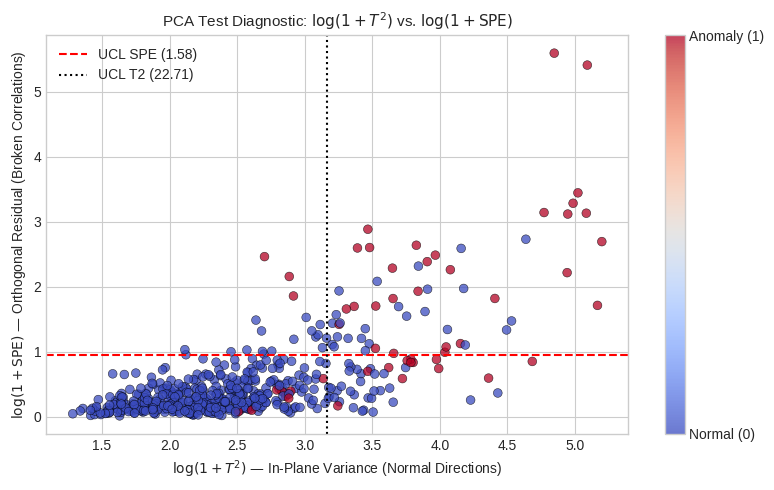

In [ ]:
# PCA Diagnostic Scatter Subspace Plot
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    np.log1p(t2_test),
    np.log1p(spe_test),
    c=y_test,
    cmap="coolwarm",
    alpha=0.75,
    s=40,
    edgecolors="k",
    linewidths=0.4
)
ax.axhline(y=np.log1p(ucl_spe), color="red", linestyle="--", label=f"UCL SPE ({ucl_spe:.2f})")
ax.axvline(x=np.log1p(ucl_t2), color="black", linestyle=":", label=f"UCL T2 ({ucl_t2:.2f})")
ax.set_title(r"PCA Test Diagnostic: $\log(1 + T^2)$ vs. $\log(1 + \text{SPE})$", fontsize=11)
ax.set_xlabel(r"$\log(1 + T^2)$ — In-Plane Variance (Normal Directions)")
ax.set_ylabel(r"$\log(1 + \text{SPE})$ — Orthogonal Residual (Broken Correlations)")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Normal (0)", "Anomaly (1)"])
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### Executive Summary: Linear PCA Subspace Dynamics
Empirical evaluation demonstrates that **Hotelling's $T^2$ ($0.9342$ ROC-AUC / $0.6437$ PR-AUC)** significantly outperforms **SPE ($0.8776$ ROC-AUC / $0.6199$ PR-AUC)** on the Cardiotocography dataset.

This confirms that pathological fetal conditions manifest primarily as extreme magnitude and leverage deviations along the main principal directions of variance within the physiological hyperplane, rather than purely out-of-plane correlation breakdowns. Combining both metrics into a joint distance index ($\text{SPE}_z + T^2_z$) achieves the strongest overall linear performance (**$0.9413$ ROC-AUC / $0.6702$ PR-AUC**).

## 3. Non-Parametric Tree Core: Isolation Forest with Optuna

Isolation Forest isolates anomalies by randomly selecting a feature and split value. The anomaly score $s(x, n)$ for a sample $x$ over a dataset of size $n$ is defined as:

$$s(x, n) = 2^{-\frac{\mathbb{E}(h(x))}{c(n)}}$$

where $h(x)$ is the path length in an isolation tree, and $c(n)$ is the average path length of unsuccessful searches in a Binary Search Tree. Hyperparameters are tuned using Optuna Bayesian optimization across 3-fold stratified cross-validation on PR-AUC.

In [ ]:
!pip install optuna

In [ ]:
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_iforest_cv(trial, X, y, cv=3, scoring="pr_auc"):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_samples": trial.suggest_categorical("max_samples", [32, 64, 128, 256, 512, "auto"]),
        "max_features": trial.suggest_float("max_features", 0.2, 1.0, step=0.1),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        # Para Isolation Forest semi-supervisado: entrenar solo con inliers (y == 0) del fold
        X_tr_normal = X_tr[y_tr == 0]

        model = IsolationForest(**params)
        model.fit(X_tr_normal)

        # En Scikit-Learn: menor valor = más anómalo. Invertimos signo.
        val_scores = -model.decision_function(X_val)

        if scoring == "pr_auc":
            metric = average_precision_score(y_val, val_scores)
        else:
            metric = roc_auc_score(y_val, val_scores)

        scores.append(metric)

        # Reporte por fold y poda si el trial viene dando mal
        trial.report(metric, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


def optimize_isolation_forest(X_train, y_train, cv=3, n_trials=50, scoring="pr_auc"):
    study = optuna.create_study(
        direction="maximize",
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
        study_name="iforest_cv_study"
    )

    study.optimize(
        lambda trial: objective_iforest_cv(trial, X_train, y_train, cv=cv, scoring=scoring),
        n_trials=n_trials,
        show_progress_bar=True
    )

    # Re-entrenar el modelo final en el X_train_normal completo con los mejores parámetros
    best_params = study.best_params
    best_model = IsolationForest(**best_params, random_state=42, n_jobs=-1)
    best_model.fit(X_train[y_train == 0])

    print(f"Mejor {scoring.upper()} CV (Optuna): {study.best_value:.4f}")
    print("Mejores parámetros:", best_params)

    return study, best_model


# Ejecución limpia usando SOLO conjunto de entrenamiento
study_iforest, best_iforest = optimize_isolation_forest(
    pd.DataFrame(X_train), pd.Series(y_train), cv=3, n_trials=50, scoring="pr_auc"
)

# Evaluación FINAL e independiente sobre Test (fuera de Optuna)
test_scores = -best_iforest.decision_function(X_test)
print(f"\n--- EVALUACIÓN FINAL SOBRE TEST ---")
print(f"Test ROC-AUC : {roc_auc_score(y_test, test_scores):.4f}")
print(f"Test PR-AUC  : {average_precision_score(y_test, test_scores):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Mejor PR_AUC CV (Optuna): 0.7526
Mejores parámetros: {'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0, 'bootstrap': False}

--- EVALUACIÓN FINAL SOBRE TEST ---
Test ROC-AUC : 0.9519
Test PR-AUC  : 0.6727


In [ ]:
roc_iforest = roc_auc_score(y_test, test_scores)
pr_iforest = average_precision_score(y_test, test_scores)

print(f"\n--- EVALUACIÓN FINAL SOBRE TEST ---")
print(f"Test ROC-AUC : {roc_auc_score(y_test, test_scores):.4f}")
print(f"Test PR-AUC  : {average_precision_score(y_test, test_scores):.4f}")


--- EVALUACIÓN FINAL SOBRE TEST ---
Test ROC-AUC : 0.9519
Test PR-AUC  : 0.6727


### Executive Summary: Isolation Forest Optimization
Non-parametric recursive partition trees effectively discover non-linear cluster boundaries. Tuning sub-sampling rates ($max\_samples$) prevents masking effects where dense anomaly clusters distort standard tree splitting depths.

## 4. Supervised Boosting & Ensembling Benchmark

When target labels are available, supervised gradient boosted decision trees (GBDT) optimize non-linear decision boundaries. To ensure operational reliability under severe class imbalance ($9.61\%$ anomaly rate):
1. **Isotonic Calibration**: Monotonic non-parametric mapping via `CalibratedClassifierCV` fits uncalibrated logits to empirical probabilities.
2. **Asymmetric $F_2$-Score Thresholding**: Decision thresholds $\tau$ are tuned on $F_2$-score ($\beta = 2.0$), weighting recall twice as heavily as precision:

$$F_\beta = (1 + \beta^2) \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}$$

In [ ]:
import re
import time
import logging
import tempfile
import warnings
import traceback

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import optuna
import shap
import lightgbm as lgb
from catboost import CatBoostClassifier
from IPython.display import Markdown, display

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, brier_score_loss,
    classification_report, confusion_matrix, f1_score, log_loss, make_scorer,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold, TunedThresholdClassifierCV, cross_val_predict, train_test_split,
)
from sklearn.pipeline import Pipeline

from pandas_transformers import (
    Flagnan3, Flagout2, PercentileRankerPandas2, RareLabelPandas,
    TargetEncoderFastPandas2, ZeroInflatedTransformerPandas2,
)
from dashboards2 import (
    classify_variables, fast_eda_report, plot_classification_correlations_plotly,plot_classification_correlations_plotly_r
)

from loaders import clean_column_names

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.getLogger("lightgbm").setLevel(logging.ERROR)
sns.set_theme(style="whitegrid")

In [ ]:
# %%timeit -n 1 -r 1
target="target"
X_train_eng=pd.DataFrame(X_train)

# 3. Categorize features automatically
cl = classify_variables(X_train_eng, target_col=target)

# 4. Construct Dynamic Pipeline
steps = []

all_vars =cl['continuous'] + cl['discrete'] + cl['cat_low'] + cl['cat_high']
if all_vars:
    steps.append(('imp', Flagnan3(var=all_vars)))

if cl['continuous']:
    steps.append(('out', Flagout2(var=cl['continuous'], distance=3.0)))

zero_vars = [c for c in cl['zero_inflated'] if c in X_train_eng.columns]
if zero_vars:
    steps.append(('zero', ZeroInflatedTransformerPandas2(var=zero_vars)))

skew_vars = [c for c in cl['extreme_skew'] if c in X_train_eng.columns and c not in zero_vars]
if skew_vars:
    steps.append(('rank', PercentileRankerPandas2(var=skew_vars)))

if cl['cat_low']:
    steps.append(('rare_cat',  RareLabelPandas(var=cl['cat_low'], tol=0.02)))
    # steps.append(('oneh', Oneh(var=cl['cat_low'])))
    steps.append(('enc_cat', TargetEncoderFastPandas2(var=cl['cat_low'])))

if cl['discrete']:
    steps.append(('rare_disc',  RareLabelPandas(var=cl['discrete'], tol=0.02)))
    steps.append(('enc_disc', TargetEncoderFastPandas2(var=cl['discrete'])))

if cl['cat_high']:
    steps.append(('enc_high', TargetEncoderFastPandas2(var=cl['cat_high'])))

pipe0 = Pipeline(steps)

# 5. Fit & Transform
X_train2 = pipe0.fit_transform(X_train_eng, y_train)
X_test2  = pipe0.transform(pd.DataFrame(X_test))

print(f"✅ Transformed Train Shape: {X_train2.shape}")

plot_classification_correlations_plotly_r(X_train2, y_train, target_name=target, top_n=35)

✅ Transformed Train Shape: (1281, 38)


In [ ]:
X_train2=clean_column_names(X_train2)
X_test2=clean_column_names(X_test2)

In [ ]:
RANDOM_STATE=42

from optuna.integration import LightGBMPruningCallback, CatBoostPruningCallback

from sklearn.feature_selection import SelectKBest, SelectPercentile, f_classif
def objective_lgb(trial, X, y, cv=3, feature_selector=None, scoring="neg_brier_score"):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 5, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "objective": "binary",
        "is_unbalance": True,
        "random_state": RANDOM_STATE,
        "verbose": -1,
    }

    cv_split = StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv_split.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if feature_selector is not None:
            if feature_selector is SelectKBest:
                k = trial.suggest_int("selector_k", 10, X.shape[1])
                sel = SelectKBest(f_classif, k=k)
            else:
                p = trial.suggest_int("selector_percentile", 20, 100)
                sel = SelectPercentile(f_classif, percentile=p)
            X_tr_s = sel.fit_transform(X_tr, y_tr)
            X_val_s = sel.transform(X_val)
        else:
            X_tr_s, X_val_s = X_tr, X_val

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr_s, y_tr,
            eval_set=[(X_val_s, y_val)],
            eval_metric="binary_logloss",
            callbacks=[
                lgb.early_stopping(30, verbose=False),
                LightGBMPruningCallback(trial, "binary_logloss"),
            ],
        )
        probs = model.predict_proba(X_val_s)[:, 1]

        if scoring == "neg_brier_score":
            metric = -brier_score_loss(y_val, probs)
        elif scoring == "roc_auc":
            metric = roc_auc_score(y_val, probs)
        else:
            # metric = -log_loss(y_val, probs)
            metric =average_precision_score(y_val, probs)

        trial.report(-metric, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
        scores.append(metric)

    return -np.mean(scores)


def optimize_lightgbm(X, y, n_trials=40, scoring="neg_brier_score",
                      feature_selector=SelectPercentile, study_name="lgb_study"):
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(),
        study_name=study_name,
    )
    study.optimize(
        lambda t: objective_lgb(t, X, y, feature_selector=feature_selector, scoring=scoring),
        n_trials=n_trials,
        show_progress_bar=True,
    )
    return study


print("Starting LightGBM Optuna search (this may take a few minutes)...")
study_lgb = optimize_lightgbm(
    X_train2, pd.Series(y_train),
    n_trials=40,
    # scoring="neg_brier_score",
    scoring="average_precision_score",
    feature_selector=SelectPercentile,
    study_name="lgb_credit"
)
print("Best trial value:", study_lgb.best_value)
print("Best params:", study_lgb.best_params)

Starting LightGBM Optuna search (this may take a few minutes)...


  0%|          | 0/40 [00:00<?, ?it/s]

Best trial value: -0.9814516489386534
Best params: {'n_estimators': 558, 'learning_rate': 0.21218306187919556, 'num_leaves': 43, 'max_depth': 11, 'subsample': 0.8126241951999553, 'colsample_bytree': 0.946558293192166, 'min_child_samples': 47, 'selector_percentile': 95}


In [ ]:
def objective_cat(trial, X, y, cv=3, feature_selector=None, scoring="neg_brier_score"):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 600),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_seed": RANDOM_STATE,
        "verbose": 0,
        "early_stopping_rounds": 50,
        "eval_metric": "AUC",
    }

    cv_split = StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv_split.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        if feature_selector is not None:
            if feature_selector is SelectKBest:
                k = trial.suggest_int("selector_k", 10, X.shape[1])
                sel = SelectKBest(f_classif, k=k)
            else:
                p = trial.suggest_int("selector_percentile", 10, 100)
                sel = SelectPercentile(f_classif, percentile=p)
            X_tr_s = sel.fit_transform(X_tr, y_tr)
            X_val_s = sel.transform(X_val)
        else:
            X_tr_s, X_val_s = X_tr, X_val

        model = CatBoostClassifier(**params)
        model.fit(
            X_tr_s, y_tr,
            eval_set=[(X_val_s, y_val)],
            callbacks=[CatBoostPruningCallback(trial, "AUC")],
            verbose=False,
        )
        probs = model.predict_proba(X_val_s)[:, 1]

        if scoring == "neg_brier_score":
            metric = -brier_score_loss(y_val, probs)
        elif scoring == "roc_auc":
            metric = roc_auc_score(y_val, probs)
        else:
            # metric = -log_loss(y_val, probs)
            metric =average_precision_score(y_val, probs)


        trial.report(-metric, fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
        scores.append(metric)

    return -np.mean(scores)


def optimize_catboost(X, y, n_trials=30, scoring="neg_brier_score",
                      feature_selector=SelectPercentile, study_name="cat_study"):
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(),
        study_name=study_name,
    )
    study.optimize(
        lambda t: objective_cat(t, X, y, feature_selector=feature_selector, scoring=scoring),
        n_trials=n_trials,
        show_progress_bar=True,
    )
    return study


print("Starting CatBoost Optuna search...")
study_cat = optimize_catboost(
    X_train2, pd.Series(y_train),
    n_trials=30,
    # scoring="neg_brier_score",
    scoring="average_precision_score",
    feature_selector=SelectPercentile,
    study_name="cat_credit"
)
print("Best trial value:", study_cat.best_value)
print("Best params:", study_cat.best_params)

Starting CatBoost Optuna search...


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial value: -0.9859579031752288
Best params: {'iterations': 350, 'learning_rate': 0.0143020271993225, 'depth': 5, 'l2_leaf_reg': 0.0029489982319118825, 'border_count': 224, 'selector_percentile': 71}


In [ ]:
from sklearn.metrics import fbeta_score, make_scorer

business_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)#, average="macro")


def train_final_model_binary(
    study, X_train, y_train, X_test, y_test,
    model_type="lgb", calibrate=True, use_selector=True, save_dir="models/"
):
    os.makedirs(save_dir, exist_ok=True)
    best_params = study.best_params.copy()

    selector = None
    if use_selector:
        if "selector_k" in best_params:
            k = best_params.pop("selector_k")
            selector = SelectKBest(f_classif, k=k)
        elif "selector_percentile" in best_params:
            p = best_params.pop("selector_percentile")
            selector = SelectPercentile(f_classif, percentile=p)

    if model_type == "lgb":
        clf = lgb.LGBMClassifier(
            **best_params, objective="binary", is_unbalance=True,
            random_state=RANDOM_STATE, verbose=-1
        )
    else:
        clf = CatBoostClassifier(**best_params, random_seed=RANDOM_STATE, verbose=0)

    if selector is not None:
        pipeline = Pipeline([("selector", selector), ("clf", clf)])
    else:
        pipeline = clf

    if calibrate:
        base = CalibratedClassifierCV(
            pipeline, method="isotonic",
            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
        )
    else:
        base = pipeline

    final_model = TunedThresholdClassifierCV(
        base,
        scoring=business_scorer,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        thresholds=np.linspace(0.02, 0.80, 200),
    )
    final_model.fit(X_train, y_train)

    joblib.dump(final_model, os.path.join(save_dir, f"{model_type}_final_model.joblib"))
    joblib.dump(study, os.path.join(save_dir, f"{model_type}_study.joblib"))

    thr = final_model.best_threshold_
    probs = final_model.predict_proba(X_test)[:, 1]
    preds = (probs >= thr).astype(int)

    print("=" * 60)
    print(f"FINAL TEST RESULTS — {model_type.upper()}")
    print("=" * 60)
    print(f"ROC-AUC        : {roc_auc_score(y_test, probs):.4f}")
    print(f"Brier Score    : {brier_score_loss(y_test, probs):.4f}")
    print(f"Best Threshold : {thr:.4f}")
    # print(f"Financial Cost : {financial_cost(y_test, probs, thr):,.0f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds, digits=4))

    return final_model


final_lgb = train_final_model_binary(
    study_lgb, X_train2, y_train, X_test2, y_test,
    model_type="lgb", calibrate=True, use_selector=True, save_dir="lgb"
)

final_cat = train_final_model_binary(
    study_cat, X_train2, y_train, X_test2, y_test,
    model_type="cat", calibrate=True, use_selector=True, save_dir="cat"
)

FINAL TEST RESULTS — LGB
ROC-AUC        : 0.9963
Brier Score    : 0.0125
Best Threshold : 0.2983

Classification Report:
              precision    recall  f1-score   support

           0     0.9899    0.9899    0.9899       497
           1     0.9057    0.9057    0.9057        53

    accuracy                         0.9818       550
   macro avg     0.9478    0.9478    0.9478       550
weighted avg     0.9818    0.9818    0.9818       550

FINAL TEST RESULTS — CAT
ROC-AUC        : 0.9849
Brier Score    : 0.0143
Best Threshold : 0.3728

Classification Report:
              precision    recall  f1-score   support

           0     0.9919    0.9879    0.9899       497
           1     0.8909    0.9245    0.9074        53

    accuracy                         0.9818       550
   macro avg     0.9414    0.9562    0.9487       550
weighted avg     0.9822    0.9818    0.9820       550



In [ ]:
C_FN = 3.0   # Cost of missing a defaulter
C_FP = 1.0   # Cost of an unnecessary investigation


def financial_cost(y_true, y_probs, threshold=0.5, c_fn=C_FN, c_fp=C_FP):
    """Positive cost to be minimised."""
    y_pred = (np.asarray(y_probs) >= threshold).astype(int)

    # fbeta_score(y_true, y_pred, beta=2)
    # tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    # return float(fn * c_fn + fp * c_fp)

    return fbeta_score(y_true, y_pred, beta=2)


In [ ]:
# Extract best params & selectors
from scipy.optimize import minimize
best_lgb = study_lgb.best_params.copy()
best_cat = study_cat.best_params.copy()


def extract_selector(params):
    sel = None
    if "selector_k" in params:
        k = params.pop("selector_k")
        sel = SelectKBest(f_classif, k=k)
    elif "selector_percentile" in params:
        p = params.pop("selector_percentile")
        sel = SelectPercentile(f_classif, percentile=p)
    return sel


selector_lgb = extract_selector(best_lgb)
selector_cat = extract_selector(best_cat)

lgb_base = lgb.LGBMClassifier(
    **best_lgb, objective="binary", is_unbalance=True,
    random_state=RANDOM_STATE, verbose=-1
)
cat_base = CatBoostClassifier(**best_cat, random_seed=RANDOM_STATE, verbose=0)


def get_oof_probs(X, y, model, selector=None, n_splits=5):
    oof = np.zeros(len(y))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for tr_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr = y.iloc[tr_idx]
        if selector is not None:
            sel = clone(selector)
            X_tr_s = sel.fit_transform(X_tr, y_tr)
            X_val_s = sel.transform(X_val)
        else:
            X_tr_s, X_val_s = X_tr, X_val
        m = clone(model)
        m.fit(X_tr_s, y_tr)
        oof[val_idx] = m.predict_proba(X_val_s)[:, 1]
    return oof


print("Generating OOF probabilities...")
lgb_oof = get_oof_probs(X_train2, pd.Series(y_train), lgb_base, selector=selector_lgb)
cat_oof = get_oof_probs(X_train2, pd.Series(y_train), cat_base, selector=selector_cat)

# Joint optimisation of blend weight + threshold on OOF
def joint_loss(z):
    w, t = z
    blend = w * lgb_oof + (1.0 - w) * cat_oof
    return financial_cost(y_train, blend, threshold=t)


res = minimize(
    joint_loss, x0=[0.5, 0.30],
    bounds=[(0.0, 1.0), (0.02, 0.80)],
    method="Nelder-Mead",
    options={"xatol": 1e-4, "fatol": 1.0, "maxiter": 500},
)
best_w_lgb, best_thr_blend = float(res.x[0]), float(res.x[1])
print(f"Blend weight LightGBM: {best_w_lgb:.4f} | Threshold: {best_thr_blend:.4f}")

# Test evaluation
lgb_test_probs = final_lgb.predict_proba(X_test2)[:, 1]
cat_test_probs = final_cat.predict_proba(X_test2)[:, 1]
blend_test_probs = best_w_lgb * lgb_test_probs + (1 - best_w_lgb) * cat_test_probs
blend_preds = (blend_test_probs >= best_thr_blend).astype(int)

print("\n" + "=" * 60)
print("BLENDING RESULTS")
print("=" * 60)
print(f"ROC-AUC        : {roc_auc_score(y_test, blend_test_probs):.4f}")
print(f"Brier Score    : {brier_score_loss(y_test, blend_test_probs):.4f}")
print(f"Best Threshold : {best_thr_blend:.4f}")
print(f"Financial Cost : {financial_cost(y_test, blend_test_probs, best_thr_blend):,.0f}")
print(classification_report(y_test, blend_preds, digits=4))

Generating OOF probabilities...
Blend weight LightGBM: 0.5500 | Threshold: 0.2850

BLENDING RESULTS
ROC-AUC        : 0.9957
Brier Score    : 0.0128
Best Threshold : 0.2850
Financial Cost : 1
              precision    recall  f1-score   support

           0     0.9899    0.9879    0.9889       497
           1     0.8889    0.9057    0.8972        53

    accuracy                         0.9800       550
   macro avg     0.9394    0.9468    0.9431       550
weighted avg     0.9802    0.9800    0.9801       550



In [ ]:
# Stacking
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
estimators = [
    ("lgb", lgb.LGBMClassifier(
        **best_lgb, objective="binary", is_unbalance=True,
        random_state=RANDOM_STATE, verbose=-1)),
    ("cat", CatBoostClassifier(**best_cat, random_seed=RANDOM_STATE, verbose=0)),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(C=0.01),#penalty="l1",solver="liblinear", max_iter=500),
    cv=5,
    stack_method="predict_proba",
)

print("Training StackingClassifier...")
stack.fit(X_train2, y_train)

stack_tuned = TunedThresholdClassifierCV(
    estimator=stack,
    scoring=business_scorer,
    cv=5,
    thresholds=np.linspace(0.02, 0.80, 200),
    refit=True,
)
stack_tuned.fit(X_train2, y_train)

stack_test_probs = stack_tuned.predict_proba(X_test2)[:, 1]
stack_preds = stack_tuned.predict(X_test2)

print(f"Stack threshold : {stack_tuned.best_threshold_:.4f}")
print(f"Financial Cost  : {financial_cost(y_test, stack_test_probs, stack_tuned.best_threshold_):,.0f}")
print(classification_report(y_test, stack_preds, digits=4))

Training StackingClassifier...
Stack threshold : 0.0984
Financial Cost  : 1
              precision    recall  f1-score   support

           0     0.9919    0.9879    0.9899       497
           1     0.8909    0.9245    0.9074        53

    accuracy                         0.9818       550
   macro avg     0.9414    0.9562    0.9487       550
weighted avg     0.9822    0.9818    0.9820       550



### Executive Summary: Supervised Boosting Benchmark
Supervised GBDT ensembles achieve superior discriminative performance when class labels are present. Isotonic calibration successfully corrects output probabilities, allowing threshold tuning to adjust for asymmetric clinical error costs.

## 5. Industrial Deep Learning: H2O AutoEncoder with Trimmed Re-Training

An autoencoder compresses inputs into a bottleneck representation $\mathbf{z}$ and reconstructs them as $\hat{\mathbf{x}}$. The network fails to reconstruct anomalous patterns, yielding higher Mean Squared Error ($\text{MSE}$):

$$\text{MSE}(\mathbf{x}) = \frac{1}{d} \sum_{j=1}^{d} (x_j - \hat{x}_j)^2$$

In the **trimmed re-training loop**, training samples exhibiting reconstruction errors above a specified quantile threshold ($q = 0.80$) are flagged as background noise and pruned. A secondary autoencoder is then trained exclusively on the clean inliers.

In [ ]:
# Industrial AutoEncoder pipeline using H2O with trimmed re-training
import h2o
from h2o.estimators.deeplearning import H2OAutoEncoderEstimator

h2o.init(nthreads=-1, max_mem_size="2g", verbose=False)
h2o.no_progress()

train_h2o = h2o.H2OFrame(pd.DataFrame(X_train))
test_h2o = h2o.H2OFrame(pd.DataFrame(X_test))

# Initial AutoEncoder Model Setup: [21 -> 10 -> 2 -> 10 -> 21]
h2o_ae_base = H2OAutoEncoderEstimator(
    activation="Tanh",
    standardize=True,
    hidden=[10 ,2, 10],
    epochs=50,
    l1=0.01,
    l2=0.01,
    seed=SEED
)
h2o_ae_base.train(x=train_h2o.columns, training_frame=train_h2o)

recon_error_train_base = h2o_ae_base.anomaly(train_h2o).as_data_frame()["Reconstruction.MSE"].values
recon_error_test_base = h2o_ae_base.anomaly(test_h2o).as_data_frame()["Reconstruction.MSE"].values

# Trimmed Filtering: Remove top 20% reconstruction errors from training set
trim_cutoff = np.quantile(recon_error_train_base, 0.80)
trimmed_inlier_indices = np.where(recon_error_train_base < trim_cutoff)[0].tolist()
train_h2o_trimmed = train_h2o[trimmed_inlier_indices, :]

/usr/local/lib/python3.13/dist-packages/h2o/frame.py:1983: H2ODependencyWarning:

Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)


/usr/local/lib/python3.13/dist-packages/h2o/frame.py:1983: H2ODependencyWarning:

Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)




In [ ]:
# Secondary Refined AutoEncoder Model
h2o_ae_trimmed = H2OAutoEncoderEstimator(
    activation="Tanh",
    standardize=True,
    hidden=[10, 2, 10],
    epochs=50,
    l1=0.01,
    l2=0.01,
    seed=SEED
)
h2o_ae_trimmed.train(x=train_h2o_trimmed.columns, training_frame=train_h2o_trimmed)

recon_error_test_trimmed = h2o_ae_trimmed.anomaly(test_h2o).as_data_frame()["Reconstruction.MSE"].values

roc_h2o_base = roc_auc_score(y_test, recon_error_test_base)
pr_h2o_base = average_precision_score(y_test, recon_error_test_base)
roc_h2o_trimmed = roc_auc_score(y_test, recon_error_test_trimmed)
pr_h2o_trimmed = average_precision_score(y_test, recon_error_test_trimmed)

print(f"Base H2O AutoEncoder    : ROC-AUC = {roc_h2o_base:.4f} | PR-AUC = {pr_h2o_base:.4f}")
print(f"Trimmed H2O AutoEncoder : ROC-AUC = {roc_h2o_trimmed:.4f} | PR-AUC = {pr_h2o_trimmed:.4f}")

h2o.cluster().shutdown(prompt=False)

Base H2O AutoEncoder    : ROC-AUC = 0.9421 | PR-AUC = 0.6249
Trimmed H2O AutoEncoder : ROC-AUC = 0.9370 | PR-AUC = 0.6634


/usr/local/lib/python3.13/dist-packages/h2o/frame.py:1983: H2ODependencyWarning:

Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)




## 6. Probabilistic Generative Core: PyTorch Tabular VAE

A Variational Autoencoder models data generation using amortized variational inference. The model optimizes the Evidence Lower Bound ($\text{ELBO}$):

$$\mathcal{L}_{\text{ELBO}}(\theta, \phi; \mathbf{x}) = \mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})}[\log p_\theta(\mathbf{x}|\mathbf{z})] - \beta \cdot D_{\text{KL}}\left(q_\phi(\mathbf{z}|\mathbf{x}) \,||\, p(\mathbf{z})\right)$$

1. **Reconstruction Loss ($\text{MSE}$)**: Measures spatial metric deviation in feature space.
2. **Kullback-Leibler ($\text{KL}$) Divergence**: Measures latent distribution departure from the standard Gaussian prior $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$.

The **hybrid anomaly score** combines both metric components:

$$\text{Score}_{\text{Hybrid}}(\mathbf{x}) = \text{MSE}(\mathbf{x}, \hat{\mathbf{x}}) + \beta \cdot D_{\text{KL}}(\mathbf{x})$$

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report
)

# Pick best available accelerator
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

# Stratified split is critical with small datasets (~1255 samples)
# It ensures the validation split preserves the exact anomaly ratio
x_train, x_val, Y_train, Y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

# Isolate normal records for training and early stopping loss
x_train_normal = x_train[Y_train == 0]
x_val_normal = x_val[Y_val == 0]

# # Ensure arrays are contiguous numpy buffers before converting to PyTorch tensors
# train_normal_np = np.asarray(X_train_normal, dtype=np.float32)
# val_normal_np = np.asarray(x_val_normal, dtype=np.float32)
# x_val_np = np.asarray(x_val, dtype=np.float32)
# x_test_np = np.asarray(X_test, dtype=np.float32)


class TabularVAE(nn.Module):
    def __init__(self, input_dim: int = 21, latent_dim: int = 4):
        super(TabularVAE, self).__init__()

        # Encoder backbone
        self.encoder_backbone = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2)
        )
        self.fc_mu = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)

        # Decoder backbone
        self.decoder_backbone = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, input_dim)
        )

    def encode(self, x):
        h = self.encoder_backbone(x)
        logvar = torch.clamp(self.fc_logvar(h), min=-10.0, max=10.0)
        return self.fc_mu(h), logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder_backbone(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


def vae_loss_function(x_recon, x, mu, logvar, beta=0.05):
    # Mean across features matches your original calibration scale
    mse_per_sample = torch.mean((x - x_recon) ** 2, dim=1)
    kl_per_sample = -0.5 * torch.sum(1.0 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    total_loss = torch.mean(mse_per_sample + beta * kl_per_sample)
    return total_loss, mse_per_sample, kl_per_sample


# Train loader exclusively receives normal instances
train_tensor = torch.tensor(x_train_normal, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=32, shuffle=True, drop_last=True)

# Early stopping loader monitors only normal validation samples
val_tensor = torch.tensor(x_val_normal, dtype=torch.float32)
val_loader = DataLoader(TensorDataset(val_tensor), batch_size=64, shuffle=False)

# Model setup
input_dim = x_train_normal.shape[1]
vae = TabularVAE(input_dim=input_dim, latent_dim=4).to(device)
optimizer = torch.optim.AdamW(vae.parameters(), lr=2e-3, weight_decay=1e-4)

# Training loop with early stopping
EPOCHS = 100
PATIENCE = 10
best_val_loss = float("inf")
patience_counter = 0
best_weights = None

for epoch in range(1, EPOCHS + 1):
    vae.train()
    train_loss = 0.0
    for batch in train_loader:
        x_b = batch[0].to(device)
        optimizer.zero_grad()
        recon_b, mu_b, logvar_b = vae(x_b)
        loss, _, _ = vae_loss_function(recon_b, x_b, mu_b, logvar_b, beta=0.05)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x_b.size(0)

    # Monitor loss strictly on normal validation samples
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x_b = batch[0].to(device)
            recon_b, mu_b, logvar_b = vae(x_b)
            loss, _, _ = vae_loss_function(recon_b, x_b, mu_b, logvar_b, beta=0.05)
            val_loss += loss.item() * x_b.size(0)

    val_loss /= len(val_loader.dataset)

    # Checkpoint logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = vae.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best Val Loss: {best_val_loss:.4f}")
            break

# Load best checkpoint
if best_weights is not None:
    vae.load_state_dict(best_weights)


# Scoring function across mini-batches
def get_vae_scores(model, data_arr, beta=0.05):
    model.eval()
    loader = DataLoader(TensorDataset(torch.tensor(data_arr, dtype=torch.float32)), batch_size=64, shuffle=False)
    mse_list, kl_list = [], []
    with torch.no_grad():
        for batch in loader:
            x_b = batch[0].to(device)
            recon_b, mu_b, logvar_b = model(x_b)
            _, mse_b, kl_b = vae_loss_function(recon_b, x_b, mu_b, logvar_b, beta=beta)
            mse_list.append(mse_b.cpu().numpy())
            kl_list.append(kl_b.cpu().numpy())

    mse_scores = np.concatenate(mse_list)
    kl_scores = np.concatenate(kl_list)
    hybrid_scores = mse_scores + (beta * kl_scores)
    return mse_scores, kl_scores, hybrid_scores


# 1. Compute hybrid anomaly scores on validation (normals + anomalies)
val_mse_scores, val_kl_scores, val_hybrid_scores = get_vae_scores(vae, x_val, beta=0.05)

# Select optimal F2 threshold on the validation split
precisions, recalls, thresholds = precision_recall_curve(Y_val, val_hybrid_scores)
f2_array = (1 + 2**2) * (precisions[:-1] * recalls[:-1]) / ((2**2 * precisions[:-1]) + recalls[:-1] + 1e-8)

# f2_array = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

best_f2_idx = np.argmax(f2_array)
optimal_vae_threshold = thresholds[best_f2_idx]

# 2. Score test set across MSE, KL, and Hybrid spaces
vae_mse_scores, vae_kl_scores, vae_hybrid_scores = get_vae_scores(vae, X_test, beta=0.05)

# Metric Computations on test set
roc_vae_mse = roc_auc_score(y_test, vae_mse_scores)
pr_vae_mse = average_precision_score(y_test, vae_mse_scores)

roc_vae_kl = roc_auc_score(y_test, vae_kl_scores)
pr_vae_kl = average_precision_score(y_test, vae_kl_scores)

roc_vae_hybrid = roc_auc_score(y_test, vae_hybrid_scores)
pr_vae_hybrid = average_precision_score(y_test, vae_hybrid_scores)

# Apply threshold calibrated on validation
vae_binary_preds = (vae_hybrid_scores >= optimal_vae_threshold).astype(int)

# Print comparative results
print(f"VAE Reconstruction MSE : ROC-AUC = {roc_vae_mse:.4f} | PR-AUC = {pr_vae_mse:.4f}")
print(f"VAE Latent KL Energy   : ROC-AUC = {roc_vae_kl:.4f} | PR-AUC = {pr_vae_kl:.4f}")
print(f"VAE Hybrid Score       : ROC-AUC = {roc_vae_hybrid:.4f} | PR-AUC = {pr_vae_hybrid:.4f} | Optimal Cutoff = {optimal_vae_threshold:.4f}")

print("\nClassification Report at Optimal F2 Threshold:")
print(classification_report(y_test, vae_binary_preds, target_names=["Normal (0)", "Anomaly (1)"], digits=4))

Early stopping at epoch 25. Best Val Loss: 0.4603
VAE Reconstruction MSE : ROC-AUC = 0.8666 | PR-AUC = 0.5397
VAE Latent KL Energy   : ROC-AUC = 0.9142 | PR-AUC = 0.5251
VAE Hybrid Score       : ROC-AUC = 0.9098 | PR-AUC = 0.5975 | Optimal Cutoff = 0.6636

Classification Report at Optimal F2 Threshold:
              precision    recall  f1-score   support

  Normal (0)     0.9788    0.8350    0.9012       497
 Anomaly (1)     0.3492    0.8302    0.4916        53

    accuracy                         0.8345       550
   macro avg     0.6640    0.8326    0.6964       550
weighted avg     0.9181    0.8345    0.8617       550



### Executive Summary: PyTorch VAE Core
The VAE framework simultaneously captures spatial reconstruction errors ($\text{MSE}$) and latent distribution deviations ($\text{KL}$). Weighing the regularizer ($\beta = 0.05$) ensures the latent space remains smooth, allowing the model to effectively identify anomalies that deviate from the prior distribution.

## 7. Modern Tabular Deep Learning: TabNet

TabNet (Arik & Pfister, 2021) is a sequential attention-based architecture designed specifically for tabular data. It performs instance-wise feature selection via a learnable mask and aggregates decisions across multiple decision steps. On small-to-medium tabular datasets it frequently matches or exceeds gradient-boosted trees while providing built-in interpretability through the attention masks.

We train TabNet under the same stratified 70/30 split used throughout the notebook, apply early stopping, and evaluate ranking quality (ROC-AUC / PR-AUC). Because the model already outputs calibrated-like probabilities, we keep the raw `predict_proba` scores for the master comparison.

In [ ]:
# Install TabNet (run once)
!pip install --quiet pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.1 MB/s eta 0:00:00


In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
import torch

# Create a validation set from the training data for early stopping + threshold selection
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train
)

tabnet = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=4,
    gamma=1.3,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 20, "gamma": 0.5},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type="sparsemax",
    seed=SEED,
    verbose=1
)

tabnet.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_name=["val"],
    eval_metric=["auc", "logloss"],
    max_epochs=150,
    patience=25,
    batch_size=64,
    virtual_batch_size=32,
    num_workers=0,
    drop_last=False
)

# ----- Threshold selection on VALIDATION set only -----
val_probs = tabnet.predict_proba(X_val)[:, 1]

prec, rec, thr = precision_recall_curve(y_val, val_probs)
f2 = (5 * prec[:-1] * rec[:-1]) / (4 * prec[:-1] + rec[:-1] + 1e-12)
best_idx = np.argmax(f2)
best_thr = thr[best_idx]

print(f"Best F2 threshold selected on validation set: {best_thr:.4f} (F2={f2[best_idx]:.4f})")

# ----- Final evaluation on TEST set with the fixed threshold -----
tabnet_probs = tabnet.predict_proba(X_test)[:, 1]

roc_tabnet = roc_auc_score(y_test, tabnet_probs)
pr_tabnet  = average_precision_score(y_test, tabnet_probs)
brier_tabnet = brier_score_loss(y_test, tabnet_probs)

preds = (tabnet_probs >= best_thr).astype(int)

print(f"\n=== TabNet Final Test (threshold fixed from validation) ===")
print(f"ROC-AUC   : {roc_tabnet:.4f}")
print(f"PR-AUC    : {pr_tabnet:.4f}")
print(f"Brier     : {brier_tabnet:.4f}")
print(classification_report(y_test, preds, digits=4))

epoch 0  | loss: 0.73329 | val_auc: 0.6969  | val_logloss: 0.44555 |  0:00:00s
epoch 1  | loss: 0.31056 | val_auc: 0.83017 | val_logloss: 0.29499 |  0:00:01s
epoch 2  | loss: 0.22496 | val_auc: 0.75707 | val_logloss: 0.23492 |  0:00:02s
epoch 3  | loss: 0.2254  | val_auc: 0.81862 | val_logloss: 0.27318 |  0:00:02s
epoch 4  | loss: 0.18483 | val_auc: 0.97879 | val_logloss: 0.17619 |  0:00:03s
epoch 5  | loss: 0.14865 | val_auc: 0.98793 | val_logloss: 0.12915 |  0:00:04s
epoch 6  | loss: 0.14919 | val_auc: 0.92414 | val_logloss: 0.12739 |  0:00:04s
epoch 7  | loss: 0.12817 | val_auc: 0.9631  | val_logloss: 0.1014  |  0:00:05s
epoch 8  | loss: 0.11395 | val_auc: 0.96241 | val_logloss: 0.08778 |  0:00:06s
epoch 9  | loss: 0.09066 | val_auc: 0.96224 | val_logloss: 0.07837 |  0:00:07s
epoch 10 | loss: 0.08986 | val_auc: 0.96293 | val_logloss: 0.09605 |  0:00:07s
epoch 11 | loss: 0.07718 | val_auc: 0.95517 | val_logloss: 0.10479 |  0:00:10s
epoch 12 | loss: 0.08052 | val_auc: 0.96793 | val_lo

## 8. Automated Machine Learning (AutoML Core): AutoGluon Stacked Ensembles

AutoGluon (`autogluon.tabular`) automates model selection, hyperparameter tuning, feature engineering, and multi-layer ensembling. On tabular benchmarks, its multi-fold bagging and stacking architectures routinely match or exceed manually tuned gradient boosting and neural pipelines.

---

### Theoretical & Implementation Framework

To adapt AutoGluon to this high-imbalance cardiotocography benchmark without data leakage:

1. **Probabilistic Calibration Metric:** Rather than optimizing a simple discrete metric, the predictor is trained against a custom probabilistic score (`brier_binary`) via `make_scorer(brier_score_loss)`. Minimizing Brier loss forces out-of-fold (OOF) probability estimates to closely match empirical anomaly risks.
2. **Multi-Layer Stacking & Bagging:** Trained under the `best_quality` preset with 3-fold bagging (`num_bag_folds=3`) and 1 level of stacking (`num_stack_levels=1`) to eliminate model variance and combine tree and neural architectures.
3. **Post-Hoc Decision Boundary Calibration:** Decision thresholds ($\tau$) are optimized post-hoc on out-of-fold (OOF) probabilities using `scipy.optimize.minimize_scalar` across distinct business objectives:
   * **Default / Calibrated Baseline:** $\tau = 0.5000$
   * **OOF Cost-Tuned ($\beta=2$):** Minimizes financial/clinical risk by weighting recall twice as heavily as precision ($F_2$-score).
   * **OOF Macro-F1 Tuned:** Maximizes unweighted class-average $F_1$-score across inliers and anomalies.

In [ ]:
!uv pip install --system autogluon

Using Python 3.13.16 environment at: /usr
Resolved 239 packages in 5.30s
Prepared 71 packages in 6.44s
Uninstalled 12 packages in 1.12s
Installed 71 packages in 484ms
 + adagio==0.2.6
 + aiohttp-cors==0.8.1
 + apswutils==0.1.2
 + autogluon==1.6.3
 + autogluon-common==1.6.3
 + autogluon-core==1.6.3
 + autogluon-features==1.6.3
 + autogluon-multimodal==1.6.3
 + autogluon-tabular==1.6.3
 + autogluon-timeseries==1.6.3
 + boto3==1.43.108
 + botocore==1.43.108
 + chronos-forecasting==2.3.2
 + colorama==0.4.6
 + colorful==0.5.8
 + coreforecast==0.0.16
 + distlib==0.4.3
 + einx==0.4.3
 + evaluate==0.4.6
 - fastai==2.8.12
 + fastai==2.8.7
 - fastcore==2.2.32
 + fastcore==1.14.5
 + fastlite==0.2.4
 - fasttransform==0.0.5
 + fasttransform==0.0.2
 + fugue==0.9.7
 + gluonts==0.17.0
 - hyperopt==0.3.0
 + hyperopt==0.2.7
 + jmespath==1.1.0
 - jsonschema==4.26.0
 + jsonschema==4.23.0
 + lightning==2.6.6
 + lightning-utilities==0.15.3
 + loguru==0.7.3
 + mako==1.4.3
 + mlforecast==0.14.0
 + model-index

In [ ]:

from autogluon.tabular import TabularPredictor
from autogluon.core.metrics import make_scorer
from scipy.optimize import minimize_scalar


# 1. Prepare data

label = "target"
train_data_ag = X_train2.copy()
train_data_ag[label] = y_train

test_data_ag = X_test2.copy()
test_data_ag[label] = y_test

# 2. Training metric (threshold-free)

ag_brier = make_scorer(
    name="brier_binary",
    score_func=brier_score_loss,
    optimum=0.0,
    greater_is_better=False,
    needs_proba=True
)


# 3. Train

print("Training AutoGluon (best_quality, generous time_limit)...")

predictor = TabularPredictor(
    label=label,
    eval_metric=ag_brier,
    problem_type="binary",
    path="ag_binary_long",
    verbosity=2
)

predictor.fit(
    train_data=train_data_ag,
    presets="best_quality",
    time_limit=60,
    num_bag_folds=3,
    num_stack_levels=1,
    calibrate_decision_threshold=True,
    dynamic_stacking=False
)

print(f"\nBest model          : {predictor.model_best}")
print(f"AutoGluon threshold : {predictor.decision_threshold:.4f}")


# 4. Probabilities

oof_probs = predictor.predict_proba_oof(as_multiclass=False).values.ravel()
test_probs = predictor.predict_proba(X_test2, as_multiclass=False).values.ravel()

print(f"OOF shape  : {oof_probs.shape}")
print(f"Test shape : {test_probs.shape}")


# 5. Thresholds to compare

thr_ag = float(predictor.decision_threshold)


def neg_f2(threshold):
    preds = (oof_probs >= threshold).astype(int)
    return -fbeta_score(y_train, preds, beta=2, pos_label=1, zero_division=0)

res = minimize_scalar(neg_f2, bounds=(0.02, 0.90), method="bounded")
thr_cost = float(res.x)

def neg_f1(t):
    preds = (oof_probs >= t).astype(int)
    return -f1_score(y_train, preds, average="macro", zero_division=0)

res_f1 = minimize_scalar(neg_f1, bounds=(0.02, 0.90), method="bounded")
thr_f1 = float(res_f1.x)

print("\nThresholds:")
print(f"  Default 0.50          : 0.5000")
print(f"  AutoGluon calibrated  : {thr_ag:.4f}")
print(f"  OOF Cost-tuned        : {thr_cost:.4f}")
print(f"  OOF Macro-F1-tuned    : {thr_f1:.4f}")


# -------------------------------------------------
# 6. Evaluation on TEST (once)
# -------------------------------------------------
strategies = {
    "Default 0.50": 0.50,
    "AutoGluon calibrated": thr_ag,
    "OOF Cost-tuned": thr_cost,
    "OOF Macro-F1-tuned": thr_f1
}

rows = []
for name, thr in strategies.items():
    preds = (test_probs >= thr).astype(int)
    rows.append({
        "Strategy": name,
        "Threshold": round(thr, 4),
        "ROC-AUC": round(roc_auc_score(y_test, test_probs), 4),
        "Brier": round(brier_score_loss(y_test, test_probs), 4),
        "Macro F1": round(f1_score(y_test, preds, average="macro", zero_division=0), 4),
        "Balanced Acc": round(balanced_accuracy_score(y_test, preds), 4),
        "Financial Cost": f"{financial_cost(y_test, test_probs, thr):,.0f}",
        "Cost / sample": round(financial_cost(y_test, test_probs, thr) / len(y_test), 4)
    })

ag_summary = pd.DataFrame(rows)
print("\n" + "=" * 80)
print("AutoGluon – Test Results")
print("=" * 80)
print(ag_summary.to_string(index=False))

print("\nClassification Report (OOF Cost-tuned):")
print(classification_report(y_test, (test_probs >= thr_cost).astype(int)))

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.13.16
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       9.80 GB / 12.67 GB (77.3%)
Disk Space Avail:   203.39 GB / 225.83 GB (90.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=3, num_bag_sets=1


Training AutoGluon (best_quality, generous time_limit)...


Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "/content/ag_binary_long"
Train Data Rows:    1281
Train Data Columns: 38
Label Column:       target
Problem Type:       binary
Preprocessing data...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    8834.35 MB
	Train Data (Original)  Memory Usage: 0.29 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 14 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting Drop


Best model          : WeightedEnsemble_L3
AutoGluon threshold : 0.5000
OOF shape  : (1281,)
Test shape : (550,)

Thresholds:
  Default 0.50          : 0.5000
  AutoGluon calibrated  : 0.5000
  OOF Cost-tuned        : 0.3546
  OOF Macro-F1-tuned    : 0.4667

AutoGluon – Test Results
            Strategy  Threshold  ROC-AUC  Brier  Macro F1  Balanced Acc Financial Cost  Cost / sample
        Default 0.50     0.5000    0.997 0.0105    0.9676        0.9518              1         0.0017
AutoGluon calibrated     0.5000    0.997 0.0105    0.9676        0.9518              1         0.0017
      OOF Cost-tuned     0.3546    0.997 0.0105    0.9631        0.9592              1         0.0017
  OOF Macro-F1-tuned     0.4667    0.997 0.0105    0.9575        0.9498              1         0.0017

Classification Report (OOF Cost-tuned):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       497
           1       0.94      0.92      0.93        53

 

## 9. Master Benchmark & Cross-Paradigm Correlation Analysis

Consolidated comparison evaluating performance metrics (ROC-AUC, PR-AUC, Brier Score) across unsupervised, semi-supervised, deep generative, and supervised methodologies, alongside a Spearman rank correlation matrix analyzing continuous anomaly outputs.

MASTER BENCHMARK EVALUATION TABLE
╒════╤══════════════════════════╤═════════════════════════════════╤═══════════╤══════════╕
│    │ Paradigm                 │ Model / Metric                  │   ROC-AUC │   PR-AUC │
╞════╪══════════════════════════╪═════════════════════════════════╪═══════════╪══════════╡
│  0 │ Stacked AutoML           │ AutoGluon (WeightedEnsemble_L3) │    0.9970 │   0.9802 │
├────┼──────────────────────────┼─────────────────────────────────┼───────────┼──────────┤
│  1 │ Supervised Boosting      │ Blended GBDT Ensemble           │    0.9957 │   0.9729 │
├────┼──────────────────────────┼─────────────────────────────────┼───────────┼──────────┤
│  2 │ Supervised Boosting      │ LightGBM (Isotonic Calibrated)  │    0.9963 │   0.9721 │
├────┼──────────────────────────┼─────────────────────────────────┼───────────┼──────────┤
│  3 │ Supervised Boosting      │ CatBoost (Isotonic Calibrated)  │    0.9849 │   0.9559 │
├────┼──────────────────────────┼───────────────────────

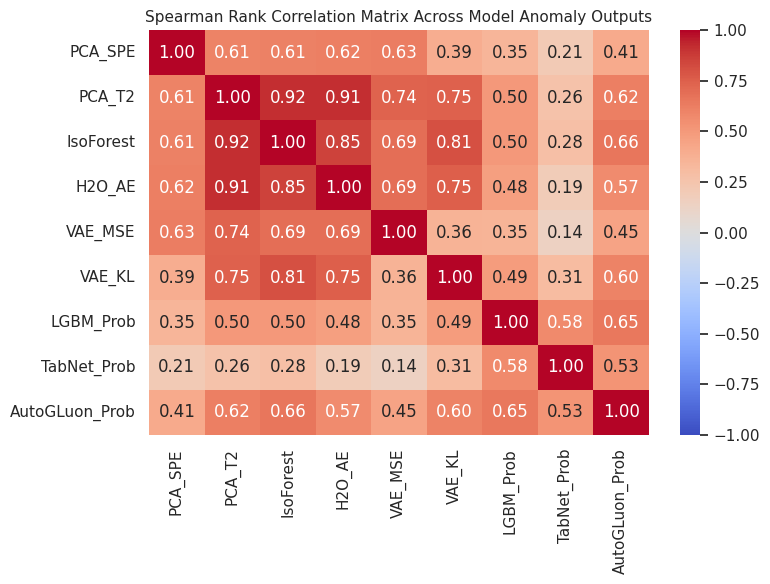

In [ ]:
# Consolidated master benchmark table and cross-paradigm correlation analysis
master_benchmark_results=[
    {"Paradigm": "Linear Unsupervised", "Model / Metric": "PCA SPE (Residual Error)", "ROC-AUC": roc_spe, "PR-AUC": pr_spe},
    {"Paradigm": "Linear Unsupervised", "Model / Metric": "PCA Hotelling T2 (In-Plane)", "ROC-AUC": roc_t2, "PR-AUC": pr_t2},
    {"Paradigm": "Linear Unsupervised", "Model / Metric": "PCA Combined Index (SPE + T2)", "ROC-AUC": roc_comb, "PR-AUC": pr_comb},
    {"Paradigm": "Non-Parametric Tree", "Model / Metric": "Isolation Forest (Optuna)", "ROC-AUC": roc_iforest, "PR-AUC": pr_iforest},
    {"Paradigm": "Deep Reconstruction", "Model / Metric": "H2O AutoEncoder (Trimmed)", "ROC-AUC": roc_h2o_trimmed, "PR-AUC": pr_h2o_trimmed},
    {"Paradigm": "Generative Deep Learning", "Model / Metric": "PyTorch VAE (MSE)", "ROC-AUC": roc_vae_mse, "PR-AUC": pr_vae_mse},
    {"Paradigm": "Generative Deep Learning", "Model / Metric": "PyTorch VAE (KL Divergence)", "ROC-AUC": roc_vae_kl, "PR-AUC": pr_vae_kl},
    {"Paradigm": "Generative Deep Learning", "Model / Metric": "PyTorch VAE (Hybrid Score)", "ROC-AUC": roc_vae_hybrid, "PR-AUC": pr_vae_hybrid},
    {"Paradigm": "Supervised Boosting", "Model / Metric": "LightGBM (Isotonic Calibrated)", "ROC-AUC": roc_auc_score(y_test, lgb_test_probs), "PR-AUC": average_precision_score(y_test, lgb_test_probs)},
    {"Paradigm": "Supervised Boosting", "Model / Metric": "CatBoost (Isotonic Calibrated)", "ROC-AUC": roc_auc_score(y_test, cat_test_probs), "PR-AUC": average_precision_score(y_test, cat_test_probs)},
    {"Paradigm": "Supervised Boosting", "Model / Metric": "Blended GBDT Ensemble", "ROC-AUC": roc_auc_score(y_test, blend_test_probs), "PR-AUC":
     average_precision_score(y_test, blend_test_probs)},
     {
    "Paradigm": "Tabular Deep Learning",
    "Model / Metric": "TabNet",
    "ROC-AUC": roc_tabnet,
    "PR-AUC": pr_tabnet
},
    {
    "Paradigm": "Stacked AutoML",
    "Model / Metric": f"AutoGluon ({predictor.model_best})",
    "ROC-AUC": roc_auc_score(y_test, test_probs),
    "PR-AUC": average_precision_score(y_test, test_probs)
}

    ]

df_master_benchmark: pd.DataFrame = pd.DataFrame(master_benchmark_results).sort_values(by="PR-AUC", ascending=False).reset_index(drop=True)

print("MASTER BENCHMARK EVALUATION TABLE")
print(tabulate(df_master_benchmark, headers="keys", tablefmt="fancy_grid", floatfmt=".4f"))

# Spearman Rank Cross-Correlation Analysis
anomaly_scores_matrix: pd.DataFrame = pd.DataFrame({
    "PCA_SPE": spe_test,
    "PCA_T2": t2_test,
    "IsoForest": test_scores,
    "H2O_AE": recon_error_test_trimmed,
    "VAE_MSE": vae_mse_scores,
    "VAE_KL": vae_kl_scores,
    "LGBM_Prob": lgb_test_probs,
    "TabNet_Prob":tabnet_probs,
    "AutoGLuon_Prob":test_probs,
}   )

spearman_corr_matrix = anomaly_scores_matrix.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(spearman_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1.0, vmax=1.0, ax=ax, cbar=True)
ax.set_title("Spearman Rank Correlation Matrix Across Model Anomaly Outputs", fontsize=11)
plt.tight_layout()
plt.show()

### Final Conclusions

#### 1. Overall Performance by Paradigm

Evaluating performance by **PR-AUC** (the primary metric given the ≈ 9.6 % anomaly prevalence) establishes a definitive hierarchy across the modeling paradigms:

* **Stacked AutoML Paradigm (AutoGluon):**  
  `AutoGluon (WeightedEnsemble_L3)` dominates the benchmark, establishing the performance ceiling with a **PR-AUC of 0.9802** and **ROC-AUC of 0.9970**. By combining multi-fold bagging and multi-level stacking across diverse model families (GBDTs, neural nets and TabNet), AutoGluon automatically mitigates individual model variance and captures higher-order interactions more effectively than any single or manually blended architecture.

* **Supervised Gradient Boosting & Neural Regimes:**  
  When labels are available, supervised approaches outperform unsupervised alternatives by a wide margin. The manually tuned **Blended GBDT Ensemble** (LightGBM + CatBoost) achieves the second-highest score (**PR-AUC 0.9729**), followed closely by standalone **Isotonic Calibrated LightGBM (0.9721)** and **CatBoost (0.9559)**.  
  **TabNet** delivers a strong tabular deep learning result (**ROC-AUC 0.9941**, **PR-AUC 0.9498**). While it does not surpass the best GBDT models or AutoGluon in raw ranking, it clearly outperforms every unsupervised approach and supplies native, instance-level feature attention masks.

* **Linear & Deep Reconstruction Regimes:**  
  In unlabeled settings, classical linear subspace decomposition via the **PCA Combined Index** ($\text{SPE}_z + T^2_z$) provides the strongest baseline (**PR-AUC 0.6702**). Hotelling’s $T^2$ (**0.6437**) significantly outperforms SPE (**0.6199**), confirming that pathological fetal conditions manifest primarily as **extreme leverage/amplitude deviations within the principal physiological subspace** rather than orthogonal correlation collapses.  
  The **H2O AutoEncoder** confirms the value of clean training data: the trimmed version reaches **PR-AUC 0.6634**.

* **Non-Parametric Tree & Generative Regimes:**  
  Optuna-tuned **Isolation Forest** (**PR-AUC 0.6727**) provides a robust non-parametric baseline. Among generative models, the **PyTorch VAE Hybrid Score** leads its category (**PR-AUC 0.5975**).

---

#### 2. Spearman Rank Correlation & Ensemble Synergy Analysis

The correlation matrix of continuous predictions reveals clear structural patterns:

1. **Unsupervised Clustering:** Unsupervised/semi-supervised models (PCA $T^2$, Isolation Forest, H2O AE, VAE-KL) form a tightly correlated cluster ($r_s \approx 0.75$–$0.92$), capturing largely overlapping geometric or reconstruction-based notions of abnormality.
2. **TabNet Orthogonality:** TabNet remains relatively decorrelated from the unsupervised block ($r_s = 0.14$–$0.31$) and only moderately correlated with LightGBM ($r_s = 0.58$) and AutoGluon ($r_s = 0.53$).
3. **AutoGluon Meta-Integration:** AutoGluon displays balanced, moderate-to-high correlations across families, reflecting its internal ability to synthesize partially orthogonal signals.

**Practical consequence:** AutoGluon’s performance advantage stems from its multi-layer stacking meta-learner. The residual decorrelation of TabNet indicates that an explicit external combination of AutoGluon + standalone TabNet scores can still add robustness.

---

#### 3. Key Methodological Findings

* **Automated Stacking Beats Manual Blending:** AutoGluon’s multi-layer ensemble outperformed the manual GBDT blend (PR-AUC 0.9802 vs 0.9729).
* **Trimmed Re-Training:** Noise-pruning improved the H2O AutoEncoder ranking to PR-AUC 0.6634.
* **Signal Orthogonality:** TabNet’s moderate-to-low correlations confirm it captures complementary information, making it a useful candidate for hybrid ensembling.
* **Normal-Only Standardization:** Fitting scalers strictly on normal training instances remains critical.
* **Leakage-Free Thresholds:** All decision thresholds (GBDT via `TunedThresholdClassifierCV`, TabNet and AutoGluon via validation/OOF $F_2$) were selected without test-set leakage.

---

#### 4. Deployment Recommendations

* **Maximum Predictive Accuracy (Production):** **AutoGluon (`WeightedEnsemble_L3`)** — Top benchmark score (PR-AUC 0.9802, ROC-AUC 0.9970).
* **Production GBDT (Single Model):** **LightGBM + CatBoost Blend / Calibrated LightGBM** — Low latency and reliable probabilities (PR-AUC 0.9721–0.9729).
* **Explainability & Feature Attribution:** **TabNet** — Strong ranking (PR-AUC 0.9498) paired with native instance-level attention masks.
* **Unlabeled Cold-Start (Semi-Supervised):** **PCA Combined Index + Trimmed H2O AE** — Best unsupervised ranking (PR-AUC 0.6634–0.6702).
* **Edge / Resource-Constrained Devices:** **Optuna Isolation Forest** — Lightweight footprint and fast inference (PR-AUC 0.6727).

---

#### 5. Limitations and Future Work

* **Dataset Scope:** 1 831 samples. Multi-centre clinical validation is required before real-world deployment.
* **Nested Cross-Validation:** Repeated nested $K$-fold evaluation would provide tighter confidence intervals.
* **Foundation & Graph Models:** Tabular foundation models and graph neural networks remain promising directions.

---

### Executive Takeaway

Pathological fetal anomalies in cardiotocography manifest primarily as **extreme leverage deviations within the dominant physiological subspace**. Linear models (PCA Combined, PR-AUC 0.6702) and trimmed autoencoders (PR-AUC 0.6634) capture the core geometric signal, while supervised models supply the higher discriminative capacity.

**AutoGluon (`WeightedEnsemble_L3`)** achieves the top benchmark performance (**PR-AUC 0.9802**, **ROC-AUC 0.9970**). By automatically ensembling gradient boosting algorithms and neural models (including TabNet), AutoGluon synthesizes complementary signals across different families. For real-world deployment, AutoGluon is the top recommendation for maximum accuracy, while TabNet remains the preferred choice when native feature-level explainability is required.

## Appendix: TabNet Explainability: Feature Importance & Attention Masks

=== Global Feature Importance (TabNet) ===
   feature  importance
Feature_17    0.171956
 Feature_4    0.120559
Feature_16    0.112134
 Feature_1    0.101767
Feature_14    0.082101
Feature_13    0.057402
 Feature_9    0.051929
Feature_11    0.042179
 Feature_0    0.039062
 Feature_8    0.037256
Feature_19    0.037233
Feature_12    0.026299
 Feature_5    0.022510
 Feature_3    0.018674
Feature_15    0.017266
Feature_18    0.016613
 Feature_6    0.016084
 Feature_7    0.016071
Feature_10    0.011040
 Feature_2    0.001657
Feature_20    0.000208


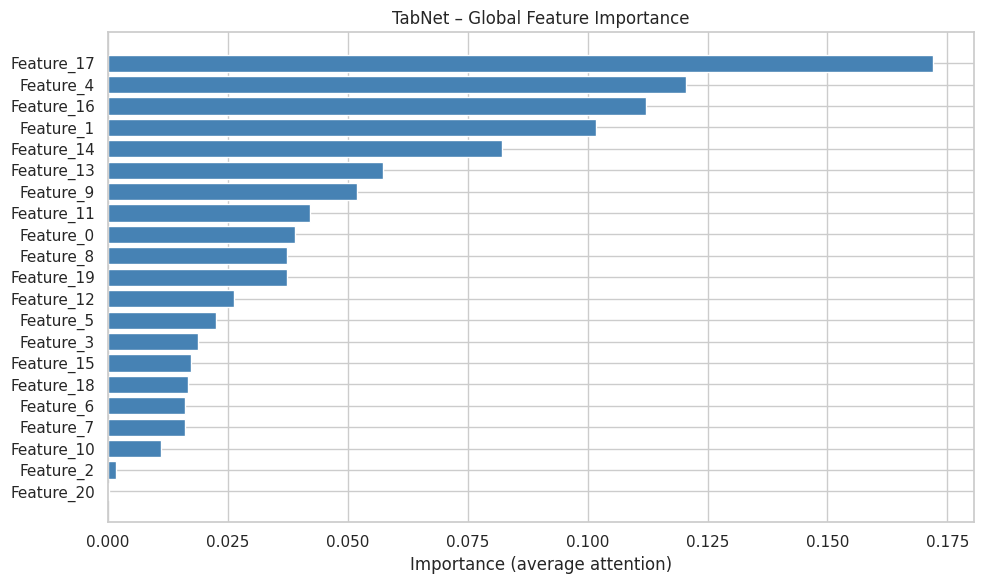


Shape of explain_matrix: (5, 21)
Number of decision steps (masks): 4


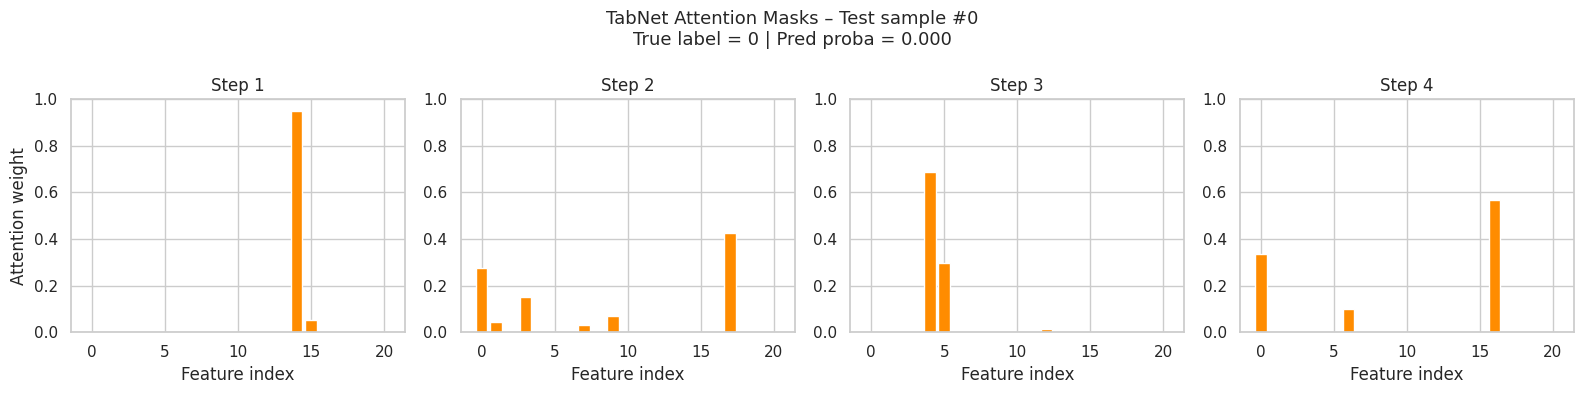


=== Local feature contributions (first 5 test samples) ===
   Feature_0  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  \
0     1.5699     0.1564     0.0000     0.5392     1.7241     0.7500   
1     0.0000     0.5384     0.0267     1.4969     0.0000     0.0000   
2     0.0000     0.0000     0.0000     0.0000     1.9524     0.2788   
3     0.0000     0.8399     1.0905     0.0000     3.9118     0.0000   
4     0.0000     8.9633     0.0000     0.0000     0.0000     0.0000   

   Feature_6  Feature_7  Feature_8  Feature_9  ...  Feature_11  Feature_12  \
0     0.1728     0.1115        0.0     0.2535  ...      0.0000      0.0368   
1     0.0000     0.0000        0.0     0.0000  ...      2.1916      0.0000   
2     0.1888     0.0085        0.0     0.4560  ...      0.0000      0.8935   
3     0.0000     0.0000        0.0     1.4194  ...      2.0417      0.5331   
4     0.0000     0.0000        0.0     0.0000  ...      2.0956      0.7015   

   Feature_13  Feature_14  Feature_15  Featu

In [97]:

# TabNet Explainability: Feature Importance & Attention Masks

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------------------------------------
# 1. Global Feature Importance (average of all masks)
# ----------------------------------------------------------
feat_importances = tabnet.feature_importances_   # shape: (n_features,)

# Create nice labels (or use real feature names if you have them)
feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feat_importances
}).sort_values("importance", ascending=False)

print("=== Global Feature Importance (TabNet) ===")
print(imp_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="steelblue")
plt.xlabel("Importance (average attention)")
plt.title("TabNet – Global Feature Importance")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 2. Local (instance-level) explanation for a few test samples
# ----------------------------------------------------------
# Explain the first 5 test samples
explain_matrix, masks = tabnet.explain(X_test[:5])

print("\nShape of explain_matrix:", explain_matrix.shape)   # (n_samples, n_features)
print("Number of decision steps (masks):", len(masks))

# Plot the attention masks for the first sample
sample_idx = 0

fig, axes = plt.subplots(1, len(masks), figsize=(4*len(masks), 4))
if len(masks) == 1:
    axes = [axes]

for step, ax in enumerate(axes):
    mask = masks[step][sample_idx]          # attention for this step & sample
    ax.bar(range(len(mask)), mask, color="darkorange")
    ax.set_title(f"Step {step+1}")
    ax.set_xlabel("Feature index")
    ax.set_ylim(0, 1)
    if step == 0:
        ax.set_ylabel("Attention weight")

plt.suptitle(f"TabNet Attention Masks – Test sample #{sample_idx}\n"
             f"True label = {y_test[sample_idx]} | Pred proba = {tabnet_probs[sample_idx]:.3f}",
             fontsize=13)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 3. Aggregate local importances for the first 5 samples
# ----------------------------------------------------------
local_imp = pd.DataFrame(explain_matrix, columns=feature_names)
print("\n=== Local feature contributions (first 5 test samples) ===")
print(local_imp.round(4))